# 04 — How a model reached 98% accuracy while knowing nothing

An earlier version of this project trained a model to predict the commission on a
deal and reported this:

> R² Score: 0.9865 (98.65% of variance explained)
> Mean Absolute Error: \$100.40
> Model performance: Excellent

That result is not real. This notebook proves it, measures exactly how much of it
was an illusion, and shows what the honest number is.

It is kept in the project on purpose. Finding the flaw in your own earlier work
and publishing the correction is more useful than a clean result that was never
questioned — and the mistake involved is the single most common way a machine
learning project quietly fails.

## The first clue was in the notebook itself

The original notebook reports 98.65% accuracy near the top. Further down, in a
cell demonstrating "real-world prediction scenarios", the same notebook prints:

> Average Prediction Accuracy: 3.0%
> High Confidence Predictions: 0/8 (0%)

Both numbers came from the same run. That contradiction is what started this
investigation.

(The 3% figure is a separate, simpler bug: that cell trained the model on raw
values and then fed it scaled values, so every prediction came out as the same
number, \$5.54. Two independent errors happened to sit in one notebook.)


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import viz

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

viz.use_style()
pd.set_option("display.width", 200)

## Step 1 — Reproduce the original result exactly

Before criticising a number we have to be able to produce it. This rebuilds the
original pipeline as it was written: the same columns dropped, the same label
encoding, the same random 80/20 split, the same model.


In [2]:
LEAKY = ["Commission_after_Tax(PKR)", "SW_Commission_PKR", "Sales_Volume"]


def original_pipeline(also_drop=(), time_split=False):
    # A faithful rebuild of the earlier notebook's modelling cells.
    df = pd.read_csv("../data/interim/textile_data_final.csv")
    df.columns = [c.strip() for c in df.columns]
    df = df.drop(columns=["Commission_SW_Percentage", "SW_Rcvd_after_Tax",
                          "Commission_PKR_Value", "Commission_Percentage",
                          "Contract_#", "Shipped_Quantity", "Payment_Days"])
    for col in ["SW_Commission_PKR", "Tax_%", "Commission_after_Tax(PKR)", "Sales_Volume"]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r"[,$ ]", "", regex=True),
                                errors="coerce")
    for col in ["Contract_Date", "Dispatch_Date", "Expected_Payment_Date"]:
        df[col] = pd.to_datetime(df[col], errors="coerce", format="mixed")

    df["Contract_length"] = (df.Dispatch_Date - df.Contract_Date).dt.days
    df["Payment_Days"] = (df["Expected_Payment_Date"] - df.Dispatch_Date).dt.days
    df["Contract_Year"] = df.Contract_Date.dt.year
    df["Contract_Month"] = df.Contract_Date.dt.month
    df["Contract_Day"] = df.Contract_Date.dt.day
    df["Payment_Month"] = df["Expected_Payment_Date"].dt.month
    year = df.Contract_Year.copy()
    df = df.drop(columns=["Contract_Date", "Dispatch_Date", "Expected_Payment_Date"])
    if also_drop:
        df = df.drop(columns=list(also_drop))

    encoder = LabelEncoder()
    for col in df.select_dtypes(include=["object", "str"]).columns:
        df[col] = encoder.fit_transform(df[col].astype(str))
    complete = df.notna().all(axis=1)
    df, year = df[complete], year[complete]

    X = df.drop(columns=["Commission_Dollar_Value"])
    y = df["Commission_Dollar_Value"]
    if time_split:
        past = year <= 2023
        X_train, X_test, y_train, y_test = X[past], X[~past], y[past], y[~past]
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    model = GradientBoostingRegressor(random_state=42).fit(scaler.fit_transform(X_train), y_train)
    predicted = model.predict(scaler.transform(X_test))
    return {"R2": r2_score(y_test, predicted),
            "MAE": mean_absolute_error(y_test, predicted),
            "features": list(X.columns), "model": model, "X_train": X_train}


original = original_pipeline()
print(f"Rebuilt here:              R2 = {original['R2']:.4f}   MAE = ${original['MAE']:.2f}")
print(f"Original notebook claimed: R2 = 0.9865   MAE = $100.40")

Rebuilt here:              R2 = 0.9877   MAE = $104.34
Original notebook claimed: R2 = 0.9865   MAE = $100.40


Reproduced. So the number was not a typo or a fluke — the pipeline really does
produce it. The question is what the model was actually using.

## Step 2 — Ask the model what it is looking at


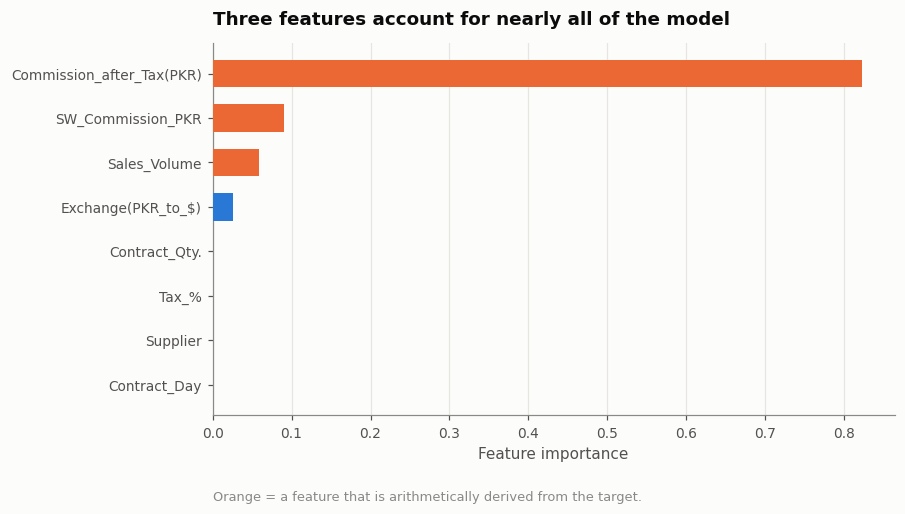

The three orange features together: 97.2% of total importance


In [3]:
importance = pd.Series(original["model"].feature_importances_,
                       index=original["X_train"].columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.4))
top = importance.head(8).iloc[::-1]
colors = [viz.SERIES[1] if name in LEAKY else viz.SERIES[0] for name in top.index]
ax.barh(range(len(top)), top.values, color=colors, height=0.62, zorder=3)
ax.set_yticks(range(len(top)), top.index)
ax.set_xlabel("Feature importance")
ax.set_title("Three features account for nearly all of the model")
viz.caption(ax, "Orange = a feature that is arithmetically derived from the target.")
viz.grid(ax, axis="x")
plt.show()

print(f"The three orange features together: {importance[LEAKY].sum():.1%} of total importance")

`Commission_after_Tax(PKR)` alone carries most of the model.

That column is the commission — the thing being predicted — converted to rupees
and reduced by tax. The model was shown the answer and asked to guess the answer.

The analogy is exact: it is like claiming you can predict someone's age to within
a year, while holding their ID card.

## Step 3 — Prove it arithmetically, not by eye

Feature importance is suggestive, not proof. The proof is that the target can be
recovered from those columns with arithmetic. If a formula reproduces the target
on nearly every row, no model was ever needed.


In [4]:
raw = pd.read_csv("../data/interim/textile_data_final.csv")
raw.columns = [c.strip() for c in raw.columns]
number = lambda s: pd.to_numeric(raw[s].astype(str).str.replace(r"[,$ ]", "", regex=True),
                                 errors="coerce")

target = raw.Commission_Dollar_Value
formulas = {
    "Commission_after_Tax(PKR) / FX / (1 - tax)":
        number("Commission_after_Tax(PKR)") / raw["Exchange(PKR_to_$)"] / (1 - number("Tax_%")),
    "SW_Commission_PKR / FX / SW share":
        number("SW_Commission_PKR") / raw["Exchange(PKR_to_$)"] / raw.Commission_SW_Percentage * raw.Commission_Percentage,
    "Sales_Volume x Commission_Percentage":
        number("Sales_Volume") * raw.Commission_Percentage,
}
rows = []
for label, reconstructed in formulas.items():
    usable = reconstructed.notna() & target.notna() & (target.abs() > 1e-9)
    within = ((reconstructed[usable] - target[usable]).abs() / target[usable].abs() < 0.01)
    rows.append({"formula": label, "rows tested": int(usable.sum()),
                 "reproduces the target": f"{within.mean():.1%}"})
pd.DataFrame(rows)

,formula,rows tested,reproduces the target
0,Commission_after_Tax(PKR) / FX / (1 - tax),4552,96.5%
1,SW_Commission_PKR / FX / SW share,4551,99.5%
2,Sales_Volume x Commission_Percentage,4554,98.9%


There it is. Each of those columns reproduces the target with plain arithmetic on
almost every row. The 98.65% was the model rediscovering a formula that was
already in the file.

## Step 4 — Measure the illusion

Now we remove the leaking columns one at a time and watch the score fall. This
turns "the result is wrong" into "here is exactly how much of it was wrong".


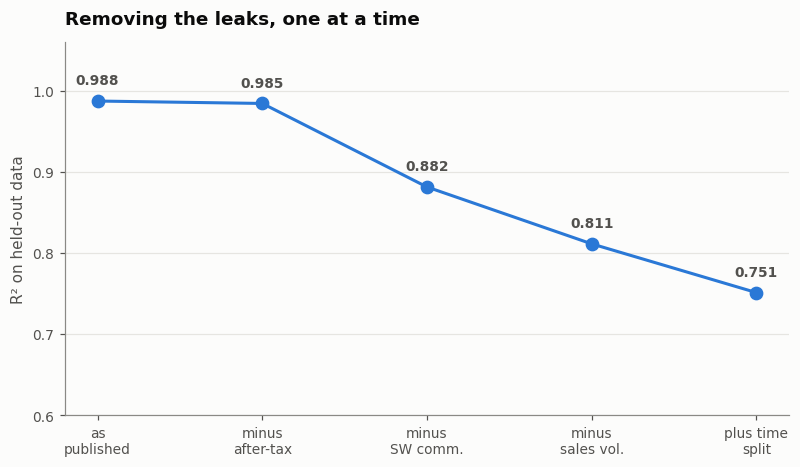

,step,R2,MAE ($)
0,"Original pipeline, as published",0.9877,104.3391
1,minus Commission_after_Tax(PKR),0.9847,167.2644
2,minus SW_Commission_PKR,0.8816,452.8629
3,minus Sales_Volume,0.8114,462.4516
4,plus a time-based split instead of random,0.7512,459.5853


In [5]:
steps = [("Original pipeline, as published", (), False)]
for i in range(1, len(LEAKY) + 1):
    steps.append((f"minus {LEAKY[i-1]}", tuple(LEAKY[:i]), False))
steps.append(("plus a time-based split instead of random", tuple(LEAKY), True))

ablation = []
for label, drop, time_split in steps:
    result = original_pipeline(also_drop=drop, time_split=time_split)
    ablation.append({"step": label, "R2": result["R2"], "MAE ($)": result["MAE"]})
ablation = pd.DataFrame(ablation)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
positions = np.arange(len(ablation))
ax.plot(positions, ablation.R2, color=viz.SERIES[0], marker="o", zorder=3)
for x, value in zip(positions, ablation.R2):
    ax.annotate(f"{value:.3f}", (x, value), xytext=(0, 11), textcoords="offset points",
                ha="center", fontsize=9, color=viz.INK_SOFT, fontweight="bold")
ax.set_xticks(positions, ["as\npublished", "minus\nafter-tax", "minus\nSW comm.",
                          "minus\nsales vol.", "plus time\nsplit"])
ax.set_ylabel("R² on held-out data")
ax.set_ylim(0.6, 1.06)
ax.set_title("Removing the leaks, one at a time")
viz.grid(ax)
plt.show()

ablation.round(4)

The published 0.9877 falls to **0.7512** once the leaking columns are gone and
the split respects time. The average error goes from \$104 to \$460 — the real
error was **four and a half times** what was reported.

Two details in that table are worth pausing on.

**Removing one leak barely moved it.** Dropping `Commission_after_Tax` alone left
R² at 0.985, because `SW_Commission_PKR` carries the same information. Leakage
is rarely one column, and patching the obvious one gives false reassurance.

**The random split was hiding something too.** Even with all three removed, a
random split still gave 0.81 while a time-based split gave 0.75. A random split
lets the model train on deals from 2024 and be tested on other deals from 2024 —
sometimes near-identical contracts split across the two halves. Real forecasting
never gets that.

## Step 5 — A check that would have caught this

The lesson is only worth something if it is reusable. `src/leakage_check.py`
runs three tests over the feature set: near-perfect correlation with the target,
a constant ratio to the target, and — the one that hides — a *pair* of features
whose product is the target.


In [6]:
from leakage_check import audit

flagged = audit(raw.drop(columns=["Commission_Dollar_Value"]), raw.Commission_Dollar_Value)
flagged

,feature,test,evidence
0,Sales_Volume x Commission_Percentage,pair multiplies to target,98.9% of rows reproduce the target
1,Commission_PKR_Value,near-perfect correlation,|r| = 0.9695
2,Commission_after_Tax(PKR),near-perfect correlation,|r| = 0.9577
3,SW_Commission_PKR,near-perfect correlation,|r| = 0.9309
4,SW_Rcvd_after_Tax,near-perfect correlation,|r| = 0.9198


Run before modelling, this takes seconds and hands back a shortlist.

It catches all three of the columns the ablation proved were leaking, plus
`SW_Rcvd_after_Tax`, which the original pipeline had already dropped for other
reasons. Note which test caught which: `Sales_Volume` correlates only 0.88 with
the target and would have slipped past a correlation screen — it is the **pair**
test that catches it, because `Sales_Volume x Commission_Percentage` reproduces
the target on 98.9% of rows. Neither of those two columns looks suspicious alone.

The screen is deliberately permissive and it is not a substitute for
understanding the data. It gives you a list to check by hand; the ablation is
what proves the case.

## Step 6 — Is the honest model even worth having?

We now have a legitimate model: R² 0.75, average error \$460. The last question
is whether it beats not having a model at all.

The comparison has to be against something a person could do without any of this
— for example, multiplying the known deal value by that customer's usual rate.


In [7]:
deals = pd.read_csv("../data/processed/deals_clean.csv", parse_dates=["contract_date"])
train, test = deals[deals.contract_year <= 2023], deals[deals.contract_year >= 2024]
actual = test.commission_usd

house_rate = train.commission_pct.median()
customer_rate = train.groupby("customer").commission_pct.median()

comparison = {
    "Everyone's average commission": np.full(len(test), train.commission_usd.median()),
    "Deal value x house rate": test.deal_value_usd * house_rate,
    "Deal value x that customer's usual rate":
        test.deal_value_usd * test.customer.map(customer_rate).fillna(house_rate),
}
scores = pd.DataFrame([
    {"method": name, "MAE ($)": mean_absolute_error(actual, pred),
     "R2": r2_score(actual, pred)}
    for name, pred in comparison.items()])
scores.loc[len(scores)] = {"method": "The honest machine learning model",
                           "MAE ($)": ablation["MAE ($)"].iloc[-1],
                           "R2": ablation.R2.iloc[-1]}
scores.sort_values("MAE ($)").round(3)

,method,MAE ($),R2
2,Deal value x that customer's usual rate,340.160,0.853
3,The honest machine learning model,459.585,0.751
1,Deal value x house rate,461.545,0.692
0,Everyone's average commission,869.652,-0.049


**A one-line multiplication beats the machine learning model.**

Multiplying the deal value — which is known before anything is signed — by that
customer's usual rate gives a lower average error than the trained model. No
training, no features, no pipeline.

That is not a failure of the model. It is a symptom of asking the wrong question.

Commission is deal value multiplied by rate. Deal value is known at signing. So
predicting the commission is really predicting the rate wearing a disguise, and
wrapping it in dollars just adds the deal's size as noise on top. The right
target was never commission dollars. It was **the rate** — which is exactly what
notebook 03 estimates directly.

## What this notebook establishes

| | Published | Actual |
|---|---|---|
| R² | 0.9865 | 0.7512 |
| Average error | \$100.40 | \$459.59 |
| Beats a one-line rule? | not tested | no |

Three specific faults, all fixable, all common:

1. **Three features were derived from the target.** Removing them cost 18 points
   of R².
2. **A random split on time-ordered data.** Correcting it cost another 6 points.
3. **No baseline.** With nothing to compare against, 98% and 75% look equally
   like success. A rule you can do in your head beats both.

None of this required a better algorithm. It required checking whether the
question was worth asking — which is the part that is easy to skip and expensive
to skip.
